<a href="https://colab.research.google.com/github/ssfatemi/DL-ML-Tutorial/blob/main/DL-python/15_Data_augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Augmentation To Address Overfitting In Flower Classification CNN

**In this notebook we will build a CNN to classify flower images. We will also see how our model overfits and how overfitting can be addressed using data augmentation. Data augmentation is a process of generating new training samples from current training dataset using transformations such as zoom, rotations, change in contrast etc**

We will download flowers dataset from google website and store it locally. In below call it downloads the zip file (.tgz) in cache_dir which is . meaning the current folder

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

<h3 style='color:purple'>Load flowers dataset</h3>

In [15]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir='.', untar=True)
# cache_dir indicates where to download data. I specified . which means current directory
# untar true will unzip it

**It has one inside folder. Therefore, I added the folder name manually**

---



In [16]:
data_dir = data_dir + '/flower_photos'
data_dir

'./datasets/flower_photos/flower_photos'

In [17]:
import pathlib
data_dir = pathlib.Path(data_dir)
data_dir

PosixPath('datasets/flower_photos/flower_photos')

In [18]:
list(data_dir.glob( '*/*.jpg'))[:5]

[PosixPath('datasets/flower_photos/flower_photos/dandelion/16953818045_fea21c8bf8.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/dandelion/14829055_2a2e646a8f_m.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/dandelion/8533312924_ee09412645_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/dandelion/479115838_0771a6cdff.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/dandelion/2502627784_4486978bcf.jpg')]

In [9]:
image_count = len(list(data_dir.glob('*/*/*.jpg')))
print(image_count)

3670


In [19]:
roses = list(data_dir.glob('roses/*'))
roses[:5]

[PosixPath('datasets/flower_photos/flower_photos/roses/4754734410_94d98463a5.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/5863698305_04a4277401_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/2197754124_5c8a146761_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/9309388105_12c0b8dd54_m.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/3705716290_cb7d803130_n.jpg')]

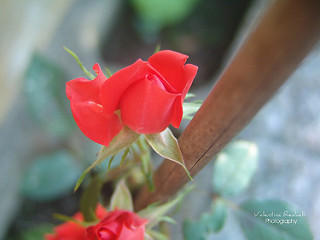

In [20]:
PIL.Image.open(str(roses[1]))

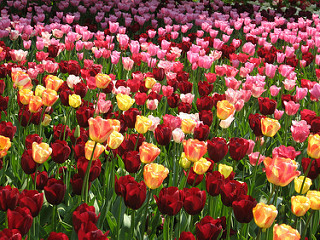

In [21]:
tulips = list(data_dir.glob('tulips/*'))
PIL.Image.open(str(tulips[0]))

Read flowers images from disk into numpy array using opencv

In [22]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}

In [23]:
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [24]:
flowers_images_dict['roses'][:5]

[PosixPath('datasets/flower_photos/flower_photos/roses/4754734410_94d98463a5.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/5863698305_04a4277401_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/2197754124_5c8a146761_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/9309388105_12c0b8dd54_m.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/3705716290_cb7d803130_n.jpg')]

In [25]:
str(flowers_images_dict['roses'][0])

'datasets/flower_photos/flower_photos/roses/4754734410_94d98463a5.jpg'

In [27]:
img = cv2.imread(str(flowers_images_dict['roses'][0]))
img.shape

(333, 500, 3)

In [28]:
cv2.resize(img,(180,180)).shape

(180, 180, 3)

In [29]:
X, y = [], []

for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(180,180))
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

In [30]:
X = np.array(X)
y = np.array(y)

<h3 style='color:purple'>Train test split</h3>

In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

<h3 style='color:purple'>Preprocessing: scale images</h3>

In [32]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

<h3 style='color:purple'>Build convolutional neural network and train it</h3>

In [33]:
num_classes = 5

model = Sequential([
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

# sparsecategorical => Becauses Classes are 1,2,3,4,5
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model.fit(X_train_scaled, y_train, epochs=30)

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.3315 - loss: 1.6380
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5474 - loss: 1.0774
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6936 - loss: 0.8282
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.7715 - loss: 0.6298
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8589 - loss: 0.4077
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9268 - loss: 0.2290
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9538 - loss: 0.1401
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9708 - loss: 0.1095
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9899 - loss: 0.0494
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9899 - loss: 0.0422
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9899 - loss: 0.0363
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy:

In [34]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.6205 - loss: 3.9051


[3.972409725189209, 0.6187363862991333]

**Here we see that while train accuracy is very high (99%), the test accuracy is significantly low (66.99%) indicating overfitting. Let's make some predictions before we use data augmentation to address overfitting**

In [35]:
predictions = model.predict(X_test_scaled)
predictions

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


array([[-12.854998  ,  31.250689  ,  -5.0993986 , -13.920832  ,
        -15.4308    ],
       [ -6.4657125 ,  13.583137  ,   0.82318753, -14.519535  ,
         -2.8964872 ],
       [-15.608588  , -11.495631  ,   3.1763399 ,   4.5086255 ,
         -2.082001  ],
       ...,
       [-14.07988   , -27.58816   , -16.750883  ,  19.78448   ,
         -4.1741667 ],
       [ 22.24019   , -24.264936  , -30.306551  , -17.934181  ,
         13.565885  ],
       [  5.140922  ,  -6.364246  , -29.568462  ,   6.098279  ,
        -13.972195  ]], dtype=float32)

In [37]:
score = tf.nn.softmax(predictions[0])
np.argmax(score)

np.int64(1)

In [36]:
y_test[0]

np.int64(1)

## Improve Test Accuracy Using Data Augmentation

In [42]:
data_augmentation = keras.Sequential(
  [
    keras.layers.RandomFlip("horizontal", input_shape=(180,
                                                              180,
                                                              3)),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
  ]
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Original Image**

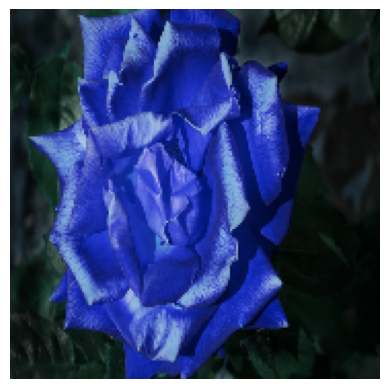

In [43]:
plt.axis('off')
plt.imshow(X[0])

**Newly generated training sample using data augmentation**


*   Flipped
*   Rotated
*   Zoomed



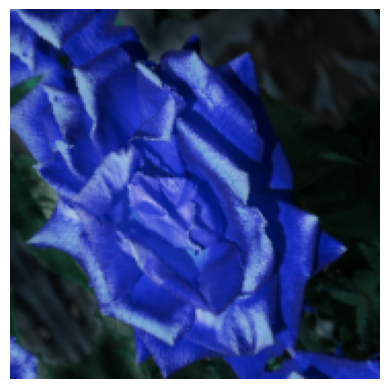

In [44]:
plt.axis('off')
plt.imshow(data_augmentation(X)[0].numpy().astype("uint8"))


<h3 style='color:purple'>Train the model using data augmentation and a drop out layer</h3>

In [45]:
num_classes = 5

model = Sequential([
  data_augmentation,
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model.fit(X_train_scaled, y_train, epochs=30)

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.3273 - loss: 1.5470
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.5961 - loss: 1.0600
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.6261 - loss: 0.9725
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.6770 - loss: 0.8634
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.6948 - loss: 0.7973
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.6958 - loss: 0.7813
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.7208 - loss: 0.7100
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.7434 - loss: 0.6666
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.7395 - loss: 0.6703
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.7539 - loss: 0.6527
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.7697 - loss: 0.6102
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy:

In [46]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7178 - loss: 1.0415


[1.042617917060852, 0.7047930359840393]

**You can see that by using data augmentation and drop out layer the accuracy of test set predictions is increased to 73.74%**